# Advanced topics

This notebook covers advanced features of NiSpace:

**Individual-level colocalization** — compute colocalization for each subject separately.  
**Individual-level deviation colocalization** — compute colocalization for each subject separately using z-score maps.  
**Dimensionality reduction** (`reduce_x()`) — summarize a large set of reference maps into a smaller number of components before colocalization.  
**Alternative colocalization methods** — partial correlation, PLS, ridge regression, and more.  

We use the ENIGMA reference datasets (`enigmathick` and `enigmaarea`) as our input maps here — these contain published cortical thickness and surface area effect sizes (Cohen's d) for many psychiatric disorders vs. healthy controls. Note that we're using *reference* data as our input maps, which, in the case of ENIGMA maps, is however often done: it lets us ask questions like "which reference systems explain patterns of grey matter alterations across psychiatric disorders?"

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [2]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.api import NiSpace

# ENIGMA cortical thickness effect sizes (Cohen's d, cases vs. controls)
# These are reference datasets — we use them as target maps (Y) here
enigma_thick = fetch_reference("enigmathick", parcellation="DesikanKilliany", collection="Adult",
                               print_references=False)
print(f"ENIGMA thickness: {enigma_thick.shape[0]} disorders x {enigma_thick.shape[1]} cortical parcels")
print("Disorders:", list(enigma_thick.index))

# Continuous resting-state network (RSN) reference maps for colocalization
pet_maps = fetch_reference("rsn", parcellation="DesikanKilliany",
                           print_references=False)
print(f"PET: {pet_maps.shape[0]} maps x {pet_maps.shape[1]} parcels")

INFO | 22/05/26 18:19:54 | nispace.datasets: Loading enigmathick maps.
INFO | 22/05/26 18:19:54 | nispace.datasets: Loading integrated collection 'Adult' for dataset 'enigmathick'.
INFO | 22/05/26 18:19:54 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 18:19:54 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'
ENIGMA thickness: 17 disorders x 68 cortical parcels
Disorders: [('dx-mdd_age-adult_pub-schmaal2017',), ('dx-adhd_age-allages_pub-hoogman2019',), ('dx-adhd_age-adult_pub-hoogman2019',), ('dx-asd_pub-vanrooij2018',), ('dx-bd_age-adult_pub-hibar2018',), ('dx-scz_pub-vanerp2018',), ('dx-ocd_age-adult_pub-boedhoe2018',), ('dx-epilepsy_pub-whelan2018',), ('dx-epilepsy_subtype-gge_pub-whelan2018',), ('dx-epilepsy_subtype-ltle_pub-whelan2018',), ('dx-epilepsy_subtype-rtle_pub-whelan2018',), ('dx-22q_pub-sun2020',), ('dx-an_pub-walton2022',), ('dx-an_subtype-acAN_pub-walton2022',), ('dx-an_subtype-pwrAN_pub-walton2022',), ('dx-antisocial_pub-gao2024',

## Individual-level colocalization

The ENIGMA dataset gives us effect size maps for multiple disorders simultaneously. We can test all disorders at once by passing the full DataFrame as `y`.

In [3]:
nsp = NiSpace(
    x=pet_maps,
    y=enigma_thick,   # all 22 disorder maps as input
    parcellation="DesikanKilliany",
    seed=42,
    n_proc=4
)
nsp.fit()
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=5000)
nsp.correct_p()

colocs = nsp.get_colocalizations()
print(f"Result: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
print(f"Result: {p_values.shape[0]} x {p_values.shape[1]} receptors")

INFO | 22/05/26 18:19:54 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 22/05/26 18:19:54 | nispace.core.parcellation: Building multi-space Parcellation for 'DesikanKilliany' from library.
INFO | 22/05/26 18:19:54 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 18:19:54 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.
INFO | 22/05/26 18:19:54 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):
INFO | 22/05/26 18:19:54 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
INFO | 22/05/26 18:19:54 | nispace.api: Got 'x' data for 14 x 68 parcels.
INFO | 22/05/26 18:19:54 | nispace.api: Checking input data for 'y' (should be, e.g., subject data):
INFO | 22/05/26 18:19:54 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING 

Colocalizing (spearman, 4 proc): 100%|██████████| 17/17 [00:03<00:00,  4.57it/s]

INFO | 22/05/26 18:19:58 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 22/05/26 18:19:58 | nispace.api: Permutation of: X maps.
INFO | 22/05/26 18:19:58 | nispace.api: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').
INFO | 22/05/26 18:19:58 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 18:19:58 | nispace.api: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 22/05/26 18:19:58 | nispace.api: Loading observed colocalizations (method = 'spearman').
INFO | 22/05/26 18:19:58 | nispace.core.permute: No null maps found.
INFO | 22/05/26 18:19:58 | nispace.core.permute: Generating null maps (n = 5000, null_method = 'alexander_bloch').
INFO | 22/05/26 18:19:58 | nispace.nulls: Null map generation: Assuming n = 14 data vector(s) for n = 68 parcels.
INFO | 22/05/26 18:19:58 | nispace.nulls: Using p


Spin null maps: 100%|██████████| 14/14 [00:00<00:00, 53.93it/s]

INFO | 22/05/26 18:19:58 | nispace.nulls: Null data generation finished.
INFO | 22/05/26 18:19:58 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:00<00:00, 7895.62it/s]


INFO | 22/05/26 18:20:00 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
Result: 17 disorders x 14 receptors
Result: 1 x 14 receptors


If we plot these data now with the automated method, what was bars before are now scatter points. Each point represents one ENIGMA cortical effect size map, respectively the disorder map's association to each reference map.  
We, by default calculate only one p value for the group-average, which here tests if there is a spatial pattern consistenly associated with ENIGMA maps *across* disorders.

INFO | 22/05/26 18:20:01 | nispace.plotting: Significance annotation: 4/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


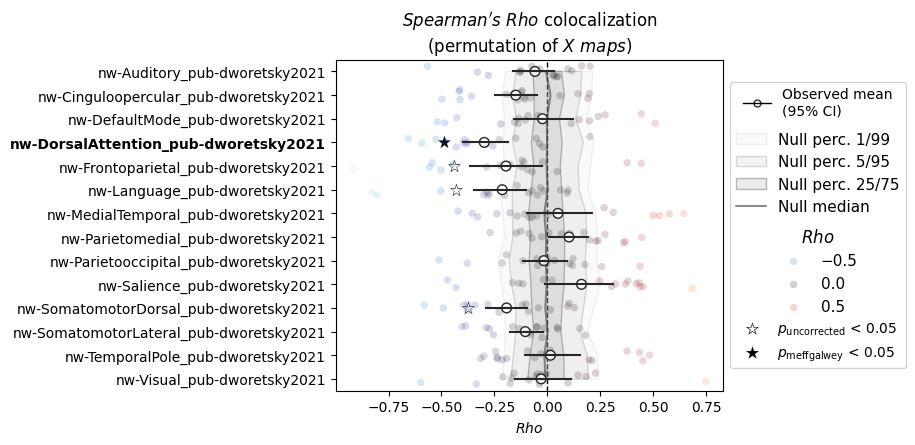

(<Figure size 500x430 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1764d9220>)

In [4]:
# plot all disorders
nsp.plot(sort_by="p")

That is interesting in itself. But we might now want to know how each individual ENIGMA map colocalizes with each individual resting-state network.  

To achieve that, we can set a flag in `NiSpace.colocalize()`, which deactivate the group-level p value computation.

In [5]:
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=5000, p_from_average_y_coloc=False)
nsp.correct_p()

# both the colocalization and the p value dataframes will now be a n_reference x n_enigma dataframe
colocs = nsp.get_colocalizations()
print(f"Result: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
pc_values = nsp.get_corrected_p_values()
print(f"Result: {p_values.shape[0]} disorders x {p_values.shape[1]} receptors")

Colocalizing (spearman, 4 proc): 100%|██████████| 17/17 [00:00<00:00, 1401.37it/s]

INFO | 22/05/26 18:20:01 | nispace.core.permute: Found existing null maps.
INFO | 22/05/26 18:20:01 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:00<00:00, 8193.15it/s]


INFO | 22/05/26 18:20:02 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
Result: 17 disorders x 14 receptors
Result: 17 disorders x 14 receptors


A heatmap is a typical means to visualize this. For now, we just use `seaborn.heatmap()` and add the p values as annotation.

<Axes: xlabel='map', ylabel='map'>

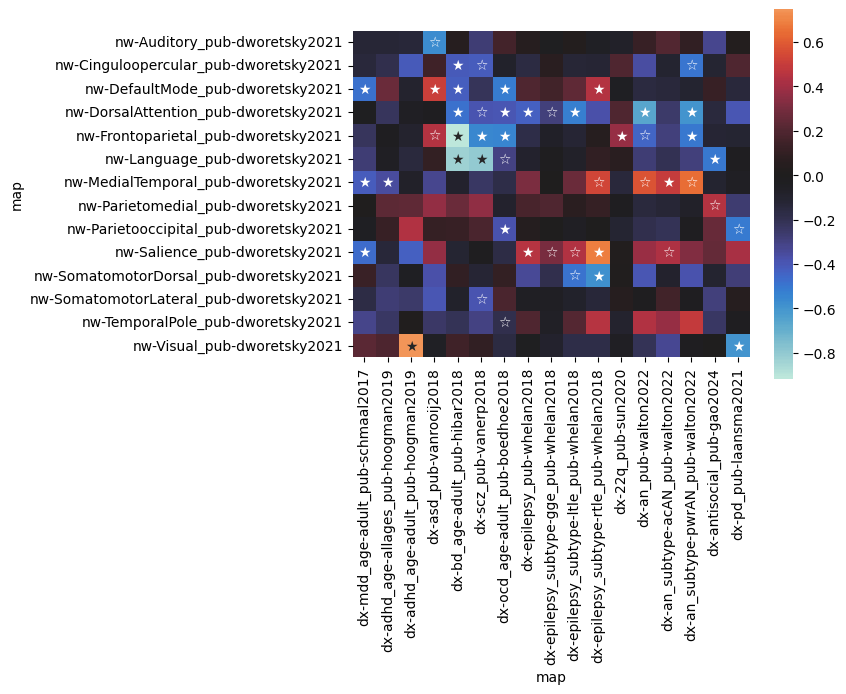

In [6]:
import seaborn as sns

sns.heatmap(
    colocs.T,
    center=0,
    square=True,
    annot=((p_values.T < 0.05).astype(int) + (pc_values.T.astype(int) < 0.05)) \
        .replace({0: "", 1: "☆", 2: "★"}),
    fmt="s"
)

## Individual-level deviation colocalization

Except for the last, the analyses so far have produced group-level results: one colocalization value per disorder or condition. But we often may want to compute colocalization for each subject individually.

The `"zscore(a,b)"` transform in `transform_y()` produces one deviation map per subject in group A (patients). We can then colocalize each map separately and look at the distribution across subjects.

This is particularly useful for stratifying patients by their colocalization profile (e.g., identifying subgroups with different neurotransmitter involvement).

We return to the anorexia nervosa example dataset here — as a reminder, it is **simulated** and not intended for scientific use.

In [7]:
from nispace.datasets import fetch_example

an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

pet_s200 = fetch_reference("pet", parcellation="Schaefer200",
                           collection="UniqueTracers", print_references=False)

nsp_indiv = NiSpace(
    x=pet_s200,
    y=an_data,
    parcellation="Schaefer200",
    seed=42,
    n_proc=4
)
nsp_indiv.fit()

# compute z-scores: each AN patient mapped relative to HC mean and SD
nsp_indiv.transform_y("zscore(a,b)", groups=groups)

print(f"Individual z-score maps: {nsp_indiv.get_y().shape}")

INFO | 22/05/26 18:20:03 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200.
INFO | 22/05/26 18:20:03 | nispace.datasets: Loading pet maps.
INFO | 22/05/26 18:20:03 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 22/05/26 18:20:03 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 18:20:03 | nispace.datasets: Loading data parcellated with 'Schaefer200'
INFO | 22/05/26 18:20:03 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 22/05/26 18:20:03 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 18:20:03 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 22/05/26 18:20:03 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 22/05/26 18:20:03 | nispace.io: Parcellated data con

In [8]:
# colocalize each subject's z-score map with PET maps
nsp_indiv.colocalize("spearman")

# result: one row per AN subject, one column per receptor
indiv_colocs = nsp_indiv.get_colocalizations()
print(f"Individual colocalizations: {indiv_colocs.shape}")
indiv_colocs.head(5)

Colocalizing (spearman, 4 proc): 100%|██████████| 50/50 [00:00<00:00, 1735.08it/s]

Individual colocalizations: (50, 29)


set                                                      General  \
map       target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
sub-001AN                                          -0.003885       
sub-002AN                                           0.090679       
sub-003AN                                           0.001941       
sub-004AN                                           0.028316       
sub-005AN                                           0.069708       

set                                                            \
map       target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
sub-001AN                                           0.051543    
sub-002AN                                           0.071480    
sub-003AN                                          -0.006407    
sub-004AN                                          -0.001380    
sub-005AN                                           0.093422    

set                                                           \
map       target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
sub-001AN                                           0.075695   
sub-002AN                                           0.093270   
sub-003AN                                          -0.039578   
sub-004AN                                           0.010208   
sub-005AN                                           0.030450   

set                                                             \
map       target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
sub-001AN                                          -0.014152     
sub-002AN                                           0.102976     
sub-003AN                                          -0.020154     
sub-004AN                                           0.046066     
sub-005AN                                           0.082838     

set                                                           \
map       target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
sub-001AN                                          -0.010520   
sub-002AN                                           0.032444   
sub-003AN                                          -0.044838   
sub-004AN                                          -0.101737   
sub-005AN                                          -0.020003   

set                                              Immunity  \
map       target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
sub-001AN                                       -0.000254   
sub-002AN                                        0.092854   
sub-003AN                                       -0.047793   
sub-004AN                                        0.133171   
sub-005AN                                        0.112293   

set                                                       \
map       target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
sub-001AN                                       0.035223   
sub-002AN                                       0.027291   
sub-003AN                                       0.019165   
sub-004AN                                       0.048498   
sub-005AN                                       0.095291   

set                                                  Glutamate  \
map       target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
sub-001AN                                           0.116639     
sub-002AN                                           0.113437     
sub-003AN                                           0.031151     
sub-004AN                                          -0.006528     
sub-005AN                                           0.080899     

set                                                            \
map       target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
sub-001AN                                           0.038085    
sub-002AN                                           0.092813    
sub-003AN                                          -0.060796    
sub-004AN                                           0.076029    
sub-

In [9]:
# for permutation testing with individual maps, we permute group labels
# p values are computed for the MEAN colocalization across subjects by default
#  -> compare to the section above
nsp_indiv.permute("groups", groups=groups, n_perm=5000)
nsp_indiv.correct_p()
p_indiv = nsp_indiv.get_p_values()

print(f"P-values shape: {p_indiv.shape}")
print(p_indiv.T.sort_values(by=p_indiv.index[0]).head(10))

INFO | 22/05/26 18:20:03 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:07<00:00, 713.88it/s]


INFO | 22/05/26 18:20:12 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
P-values shape: (1, 29)
                                                                              mean
set                     map                                                       
Serotonin               target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.0002
General                 target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.0002
Dopamine                target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.0002
GABA                    target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.0002
Serotonin               target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.0040
Dopamine                target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.0188
Opiods/Endocannabinoids target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.0200
Immunity                target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.0228
General                 target-CMRglu_tracer

INFO | 22/05/26 18:20:13 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 5/29 p_meffgalwey < 0.05


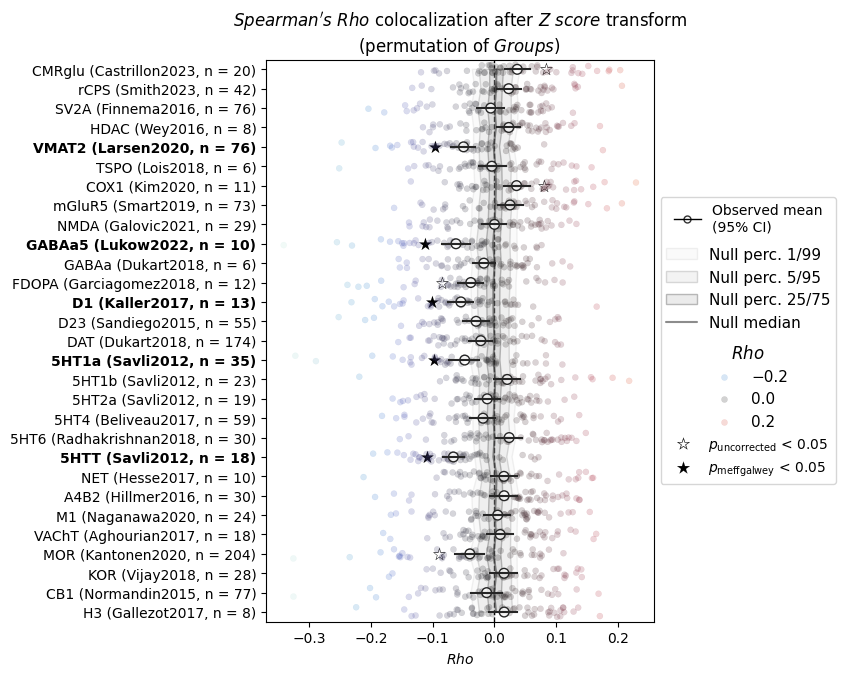

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Z\\ score$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x17dbe38b0>)

In [10]:
# plot
nsp_indiv.plot()

## Dimensionality reduction with `reduce_x()`

When you have many reference maps (30 PET tracers, thousands of genes), interpreting individual colocalizations can be difficult — and many maps are correlated with each other. `reduce_x()` summarizes the reference maps into a smaller set of components using PCA, ICA, or factor analysis.

After reduction, `colocalize()` operates on the components instead of individual maps.

In [11]:
# reduce the PET maps to their principal components
nsp.reduce_x("pca", n_components=5)  # keep 5 components

# colocalize on the reduced space
nsp.colocalize("spearman", X_reduction="pca")
nsp.permute("maps", n_perm=5000, X_reduction="pca")

pca_colocs = nsp.get_colocalizations(X_reduction="pca")
print(f"PCA colocalizations: {pca_colocs.shape[0]} disorders x {pca_colocs.shape[1]} components")
pca_colocs

INFO | 22/05/26 18:20:13 | nispace.core.reduce_x: Performing dimensionality reduction using pca (max components: 5, min EV: None).
INFO | 22/05/26 18:20:13 | nispace.core.reduce_x: Returning 5 principal component(s).


Colocalizing (spearman, 4 proc): 100%|██████████| 17/17 [00:00<00:00, 1371.74it/s]

INFO | 22/05/26 18:20:14 | nispace.core.permute: Found existing null maps.
WARNING | 22/05/26 18:20:14 | nispace.core.permute: Not all X/Y variables in null maps. Will re-generate.
INFO | 22/05/26 18:20:14 | nispace.core.permute: Generating null maps (n = 5000, null_method = 'alexander_bloch').
INFO | 22/05/26 18:20:14 | nispace.nulls: Null map generation: Assuming n = 5 data vector(s) for n = 68 parcels.
INFO | 22/05/26 18:20:14 | nispace.nulls: Using provided precomputed spin matrix.



Spin null maps: 100%|██████████| 5/5 [00:00<00:00, 47.81it/s]

INFO | 22/05/26 18:20:14 | nispace.nulls: Null data generation finished.
INFO | 22/05/26 18:20:14 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:00<00:00, 12990.21it/s]


INFO | 22/05/26 18:20:15 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
PCA colocalizations: 17 disorders x 5 components


,c0,c1,c2,c3,c4
map,,,,,
dx-mdd_age-adult_pub-schmaal2017,0.036813,-0.439281,-0.023625,-0.352965,0.086832
dx-adhd_age-allages_pub-hoogman2019,-0.158559,-0.006571,-0.245571,-0.134044,0.328010
dx-adhd_age-adult_pub-hoogman2019,-0.306817,-0.468734,-0.025975,-0.391480,0.114203
dx-asd_pub-vanrooij2018,-0.109243,0.330221,-0.736718,0.152828,0.105797
dx-bd_age-adult_pub-hibar2018,-0.246540,-0.740931,0.295463,0.351486,-0.050310
dx-scz_pub-vanerp2018,-0.335121,-0.445260,-0.042550,0.290613,-0.077961
dx-ocd_age-adult_pub-boedhoe2018,0.193012,-0.310282,0.319795,0.061663,0.096434
dx-epilepsy_pub-whelan2018,-0.224108,0.099740,0.262697,0.500091,0.139234
dx-epilepsy_subtype-gge_pub-whelan2018,-0.046783,0.079664,-0.010477,0.365697,0.194161


INFO | 22/05/26 18:20:15 | nispace.plotting: Significance annotation: 1/5 p_uncorrected < 0.05, 0/5 p_fdr_bh < 0.05 (no correction applied)


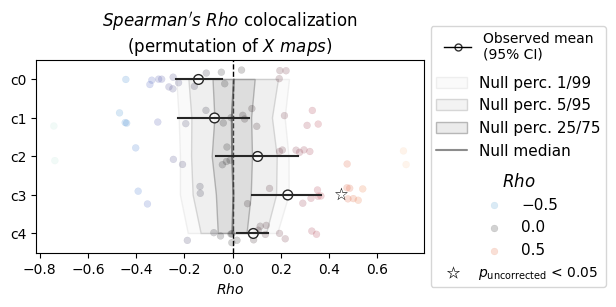

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x301385e20>)

In [12]:
nsp.plot(X_reduction="pca", mc_method="fdr_bh")

## Alternative colocalization methods

Spearman correlation is the default, but NiSpace supports several other methods. Each has different assumptions and use cases.  

Importantly, methods might return multiple different colocalization metrics. For example, a linear regression model (`"mlr"`) already returns both beta coefficients (one for each X map, as for correlations) **and** the R^2 value (one across X maps). Each of these colocalization statistics will furthermore have an associated p values after `.permute()` has been run.

In [13]:
# set up a simple analysis for comparison
nsp_methods = NiSpace(
    x=pet_maps,
    y=enigma_thick.loc[["dx-bd_age-adult_pub-hibar2018"]],  # just bipolar disorder for clarity
    parcellation="DesikanKilliany",
    seed=42
)
nsp_methods.fit()

# Pearson correlation
nsp_methods.colocalize("pearson")
pearson = nsp_methods.get_colocalizations()
print("Pearson:", pearson.values.squeeze())
print("")

# Multiple linear regression (MLR)
nsp_methods.colocalize("mlr")
mlr = nsp_methods.get_colocalizations()
print("MLR beta:", mlr["beta"].values.squeeze())
print("MLR R2:", mlr["r2"].values.squeeze())
print("")

# Partial least squares (PLS)
nsp_methods.colocalize("pls", n_components=3)
pls = nsp_methods.get_colocalizations()
print("PLS beta:", pls["beta"].values.squeeze())
print("PLS R2:", pls["r2"].values.squeeze())
print("")

# Dominance analysis (takes the longest)
nsp_methods.colocalize("dominance")
dom = nsp_methods.get_colocalizations()
print("Dominance: sum (matches MLR R2) :", dom["sum"].values.squeeze())
print("Dominance: total (sum of total is MLR R2):", dom["total"].values.squeeze())
print("Dominance: individual (like a leave-one-out MLR R2):", dom["individual"].values.squeeze())
print("Dominance: relative (fraction of sum R2):", dom["relative"].values.squeeze())


INFO | 22/05/26 18:20:15 | nispace.core.parcellation: Building multi-space Parcellation for 'DesikanKilliany' from library.
INFO | 22/05/26 18:20:15 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 22/05/26 18:20:16 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.
INFO | 22/05/26 18:20:16 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
INFO | 22/05/26 18:20:16 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


Colocalizing (pearson, 1 proc): 100%|██████████| 1/1 [00:00<00:00, 263.56it/s]


Pearson: [ 0.08143978 -0.18625194 -0.29610512 -0.28880474 -0.74379873 -0.3885152
  0.15896514  0.12016276  0.19431612  0.11815453  0.11539447  0.11960161
  0.08544999  0.28342018]



Colocalizing (mlr, 1 proc): 100%|██████████| 1/1 [00:00<00:00, 116.96it/s]


MLR beta: [-0.03424036 -0.02583259 -0.05064839 -0.02337011 -0.06296097 -0.03661125
 -0.02824637 -0.00120914 -0.0195942  -0.02056503 -0.03624874  0.0015286
 -0.0231194  -0.05032629]
MLR R2: 0.48541



Colocalizing (pls, 1 proc): 100%|██████████| 1/1 [00:00<00:00, 111.30it/s]


PLS beta: [-0.00471531 -0.01129592 -0.0184884  -0.01936056 -0.03164917 -0.01033826
 -0.0006638   0.0057384   0.00212557  0.01042274  0.00196163  0.00364956
 -0.00026549  0.00544606]
PLS R2: 0.52595305



Colocalizing (dominance, 1 proc): 100%|██████████| 1/1 [00:00<00:00,  3.61it/s]

Dominance: sum (matches MLR R2) : 0.48540986
Dominance: total (sum of total is MLR R2): [ 0.0026469   0.0164257   0.06232518  0.05829372  0.23922461  0.0619078
  0.00357207 -0.0004612   0.00469065  0.00919381  0.00415807 -0.00323443
 -0.00242823  0.02909521]
Dominance: individual (like a leave-one-out MLR R2): [-0.00844811  0.01926547  0.06889955  0.06502552  0.38959935  0.12388225
  0.01007512 -0.00063369  0.02223459 -0.00111046 -0.00175294 -0.00076778
 -0.00777491  0.06221645]
Dominance: relative (fraction of sum R2): [ 0.00545292  0.03383882  0.12839702  0.12009174  0.49283016  0.12753718
  0.00735887 -0.00095012  0.00966328  0.01894031  0.0085661  -0.00666329
 -0.00500244  0.05993947]


If we plot multi-outcome colocalization results, we will automatically get one plot for each metric. E.g., for the quite detailled dominance output:

INFO | 22/05/26 18:20:16 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 18:20:16 | nispace.core.permute: No null maps found.
INFO | 22/05/26 18:20:16 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'alexander_bloch').
INFO | 22/05/26 18:20:16 | nispace.nulls: Null map generation: Assuming n = 14 data vector(s) for n = 68 parcels.
INFO | 22/05/26 18:20:16 | nispace.nulls: Using provided precomputed spin matrix.


Spin null maps: 100%|██████████| 14/14 [00:00<00:00, 244.76it/s]

INFO | 22/05/26 18:20:16 | nispace.nulls: Null data generation finished.
INFO | 22/05/26 18:20:16 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (dominance, 4 proc): 100%|██████████| 1000/1000 [01:04<00:00, 15.57it/s]


INFO | 22/05/26 18:21:21 | nispace.core.permute: Calculating exact p-values (tails = {'sum': 'upper', 'total': 'upper', 'individual': 'upper', 'relative': 'upper'}).
INFO | 22/05/26 18:21:21 | nispace.plotting: Significance annotation: 0/1 p_uncorrected < 0.05, 0/1 p_meffgalwey < 0.05


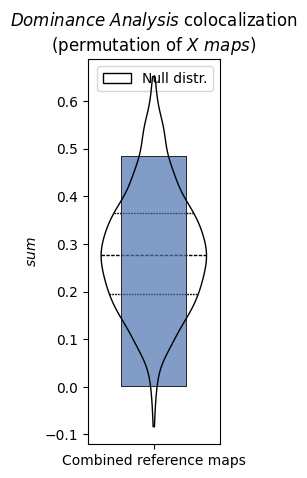

INFO | 22/05/26 18:21:21 | nispace.plotting: Significance annotation: 1/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


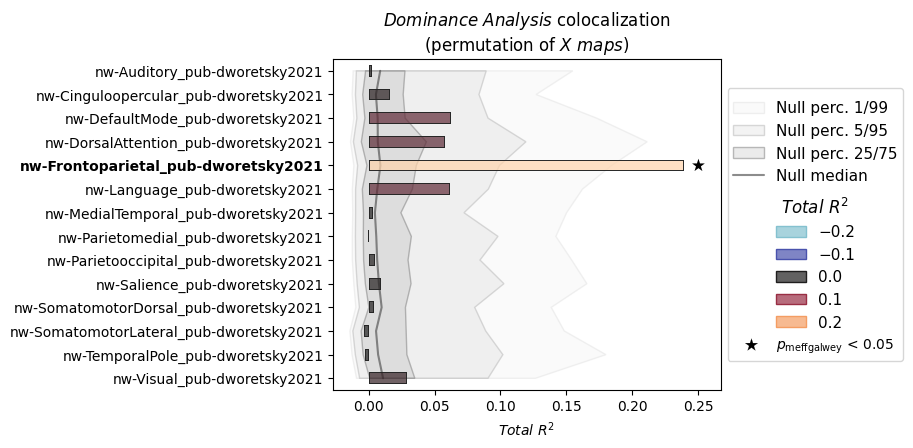

INFO | 22/05/26 18:21:21 | nispace.plotting: Significance annotation: 2/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


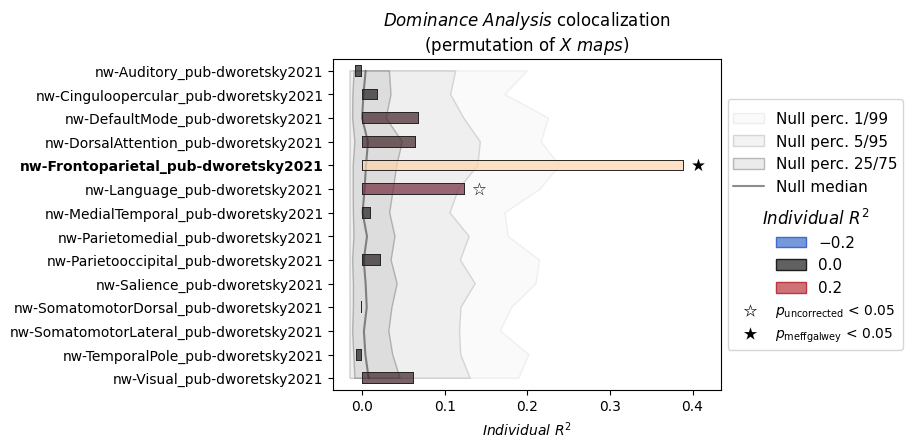

INFO | 22/05/26 18:21:21 | nispace.plotting: Significance annotation: 1/14 p_uncorrected < 0.05, 0/14 p_meffgalwey < 0.05


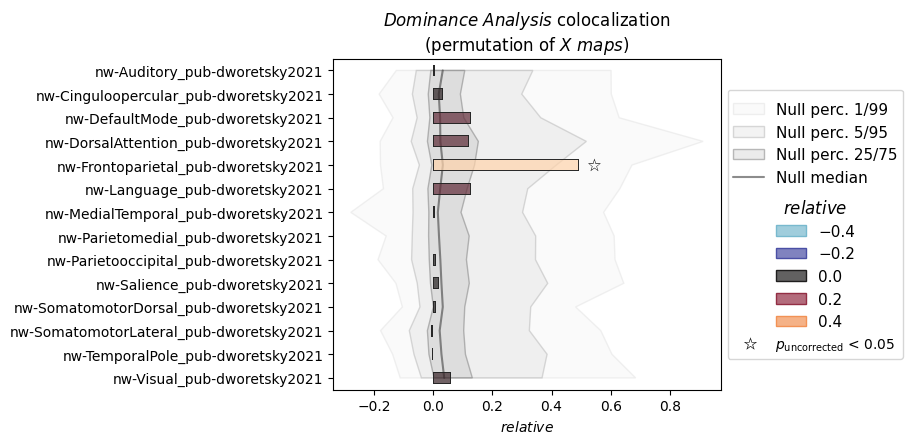

{'sum': (<Figure size 170x500 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, ylabel='$sum$'>,
  <seaborn._core.plot.Plotter at 0x306c564c0>),
 'total': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$Total\\ R^2$'>,
  <seaborn._core.plot.Plotter at 0x30710ae20>),
 'individual': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$Individual\\ R^2$'>,
  <seaborn._core.plot.Plotter at 0x30121b490>),
 'relative': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$relative$'>,
  <seaborn._core.plot.Plotter at 0x3057aa220>)}

In [14]:
# first: run the proper permutation; will take some time for dominance analysis
nsp_methods.permute("maps", n_perm=1000, n_proc=4)
nsp_methods.correct_p()

# show
nsp_methods.plot()

## Summary

| Feature | How to use |
|---------|------------|
| Individual-level colocalization | `nsp.colocalize()` + `nsp.permute(p_from_average_y_coloc=False)` |
| Individual-level deviation colocalization | `nsp.transform_y("zscore(a,b)", groups=...)` + `nsp.colocalize()` + `nsp.permute("groups")` |
| Dimensionality reduction | `nsp.reduce_x("pca", n_components=5)`, then `nsp.colocalize(..., X_reduction="pca")` |
| Alternative colocalization methods | `nsp.colocalize("partialpearson")`, `"pls"`, `"ridge"`, etc. |

This is the last notebook in the introduction series. For more, see the [API reference](../api_ref.rst) and the [Example notebooks](../examples.rst).